In [92]:
%reset -f

In [93]:
import sys
sys.path.append(r"C:\ThesisWork\offical_approach\mth_project\mth_project\industrial_network_analysis")
from data_preprocessing import Dataset
from data_utils import remove_outliers

import warnings
import logging

warnings_logger = logging.getLogger('warnings')
warnings_logger.setLevel(logging.WARNING)
warning_handler = logging.FileHandler('warnings.log')
warning_handler.setFormatter(logging.Formatter('%(asctime)s - %(levelname)s - %(message)s'))
warnings_logger.addHandler(warning_handler)

def warning_handler_func(message, category, filename, lineno, file=None, line=None):
    warnings_logger.warning(f"{category.__name__}: {message} (File: {filename}, Line: {lineno})")

warnings.showwarning = warning_handler_func

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import timesfm
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

import time
from statsmodels.tsa.api import VAR

In [94]:
### READ DATA - to get the same dataframe like for pure timesFM, for result comparison

device_name = "A1-RBX-243"
df = Dataset(f'C:\\ThesisWork\\offical_approach\\mth_project\\mth_project\\industrial_network_analysis\\Data082025\\{device_name}.csv')

# names for traffic on ports - BITS SENT/RECEIVED
bits = "bits"
bits_exclude = "unused"

def get_column_names_exclude(df, search_keyword, exclude_keyword):
    df_column_names = df.get_column_names(search_keyword)
    df_column_names_excluded = []

    for col in df_column_names:
        if exclude_keyword.lower() not in col.lower():
            df_column_names_excluded.append(col)

    return df_column_names_excluded


df_columns_bits_names = get_column_names_exclude(df, bits, bits_exclude)

df_bits = df.get_column_values(df_columns_bits_names)
df_bits.columns = df_bits.columns.str.replace('Interface Gi', '')
df_bits.columns = df_bits.columns.str.replace('Valmet SUPV switch connection', '')
df_bits.columns = df_bits.columns.str.replace('Supervisory access', '')
df_bits.columns = df_bits.columns.str.replace('Bits sent', 'out')
df_bits.columns = df_bits.columns.str.replace('Bits received', 'in')
df_bits.columns = df_bits.columns.str.replace('Valmet DNA', '')

df_bits = df_bits[:24*60]
df_bits = remove_outliers(df_bits, 3).dropna()
df_bits_train, df_bits_test = np.split(df_bits, [int(0.8 * len(df_bits))])

In [95]:
# VAR forecasting program

### 1. data preparation

# Initialize scaler
scaler = RobustScaler()

# Fit scaler only on training data
train_data_normalized = pd.DataFrame(
    scaler.fit_transform(df_bits_train),
    columns=df_bits_train.columns,
    index=df_bits_train.index
)

# Apply same transformation to test data
test_data_normalized = pd.DataFrame(
    scaler.transform(df_bits_test),
    columns=df_bits_test.columns,
    index=df_bits_test.index
)


Pure VAR model used for multicast forecasting

In [96]:
### 2. check for optimal parameters for model

# analyze optimal parameters for VAR model: maxlags and ic method
# ic_value - information criterion value, lower is better

maxlags_range = range(1, 31)
ic_methods = ['aic', 'bic', 'fpe', 'hqic']
results = []

for ic in ic_methods:
    for maxlags in maxlags_range:
        try:
            model = VAR(train_data_normalized)
            fitted = model.fit(maxlags=maxlags, ic=ic)
            results.append({
                'ic': ic,
                'maxlags': maxlags,
                'selected_lags': fitted.k_ar,
                'ic_value': getattr(fitted, ic)
            })
        except Exception as e:
            print(f"Error occurred for ic={ic}, maxlags={maxlags}: {e}")

results_df = pd.DataFrame(results)
# print(results_df)

best_results_for_VAR = results_df.loc[results_df['ic_value'].idxmin()]

maxlags = best_results_for_VAR['maxlags']
ic = best_results_for_VAR['ic']

### 3. create model VAR for variables from df_bits

VAR_model = VAR(train_data_normalized)
VAR_model_fitted = VAR_model.fit(maxlags=maxlags, ic=ic)

### 4. Forecasting

start_time = time.time()

lag_order = VAR_model_fitted.k_ar
VAR_forecast = VAR_model_fitted.forecast(train_data_normalized.values[-lag_order:], steps=len(test_data_normalized))
df_VAR_forecast = pd.DataFrame(VAR_forecast, index=test_data_normalized.index, columns=test_data_normalized.columns)

end_time = time.time()
elapsed_time = end_time - start_time

### 5. denormalization
# denormalize predictions to original scale
VAR_forecast_denormalized = pd.DataFrame(
    scaler.inverse_transform(df_VAR_forecast),
    columns=df_VAR_forecast.columns,
    index=df_VAR_forecast.index
)

# also denormalize the test data for comparison
test_data_denormalized = pd.DataFrame(
    scaler.inverse_transform(test_data_normalized),
    columns=test_data_normalized.columns,
    index=test_data_normalized.index
)

### 6. evaluation

def calculate_metrics(actual, predicted, variable_name):
    """Calculate comprehensive metrics for a single variable"""
    mae = mean_absolute_error(actual, predicted)
    mse = mean_squared_error(actual, predicted)
    rmse = np.sqrt(mse)

    return {
        'Variable': variable_name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse
    }

VAR_results = []
for col in VAR_forecast_denormalized.columns:
    actual = test_data_denormalized[col].values
    predicted = VAR_forecast_denormalized[col].values

    metrics = calculate_metrics(actual, predicted, col)
    VAR_results.append(metrics)

VAR_results_df = pd.DataFrame(VAR_results)

In [97]:
# visualization

def plot_single_variable_forecast(variable_idx, train_data_normalized, test_data_denormalized, 
                                 VAR_forecast_denormalized, scaler, results_df):

    if variable_idx >= len(VAR_forecast_denormalized.columns):
        print(f"Variable index {variable_idx} out of range. Max index: {len(VAR_forecast_denormalized.columns)-1}")
        return

    col = VAR_forecast_denormalized.columns[variable_idx]

    # Get full training data (denormalized)
    train_denormalized = pd.DataFrame(
        scaler.inverse_transform(train_data_normalized),
        columns=train_data_normalized.columns,
        index=train_data_normalized.index
    )
    
    plt.figure(figsize=(15, 8))
    
    # Plot training data
    plt.plot(train_denormalized.index, train_denormalized[col], 
             label='Training Data', color='blue', alpha=0.7)
    
    # Plot actual test data
    plt.plot(test_data_denormalized.index, test_data_denormalized[col], 
             label='Actual', color='green', linewidth=2)

    # Plot VAR forecast
    plt.plot(VAR_forecast_denormalized.index, VAR_forecast_denormalized[col],
             label='VAR Forecast', color='red', linewidth=2, linestyle='--')

    # Add vertical line at forecast start
    plt.axvline(x=test_data_denormalized.index[0], color='gray', 
                linestyle=':', alpha=0.7, label='Forecast Start')

    plt.title(f'VAR Forecast vs Actual - {col}', fontsize=14)
    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Print metrics for this variable
    metrics = results_df[results_df['Variable'] == col].iloc[0]
    print(f"Metrics for {col}:")
    print(f"MAE: {metrics['MAE']:.4f}, RMSE: {metrics['RMSE']:.4f}")

In [98]:
# Print results
for idx, col in enumerate(VAR_results_df['Variable']):
    print(f"Metrics for {col}:")
    print(f" MAE: {VAR_results_df.loc[idx, 'MAE']:.4f},\n MSE: {VAR_results_df.loc[idx, 'MSE']:.4f},\n RMSE: {VAR_results_df.loc[idx, 'RMSE']:.4f}")

Metrics for 1/1( FIREWALL connection): in:
 MAE: 33.6313,
 MSE: 1354.2049,
 RMSE: 36.7995
Metrics for 1/1( FIREWALL connection): out:
 MAE: 546397.7857,
 MSE: 363854429994.0526,
 RMSE: 603203.4731
Metrics for 1/3(Valmet PRP LAN_A-connection): in:
 MAE: 546392.1462,
 MSE: 363843962123.9045,
 RMSE: 603194.7962
Metrics for 1/3(Valmet PRP LAN_A-connection): out:
 MAE: 33.7853,
 MSE: 2097.3037,
 RMSE: 45.7963
Metrics for 1/4(Valmet PRP LAN_B-connection): in:
 MAE: 4.5607,
 MSE: 28.4956,
 RMSE: 5.3381
Metrics for 1/4(Valmet PRP LAN_B-connection): out:
 MAE: 50.7222,
 MSE: 3932.9247,
 RMSE: 62.7130


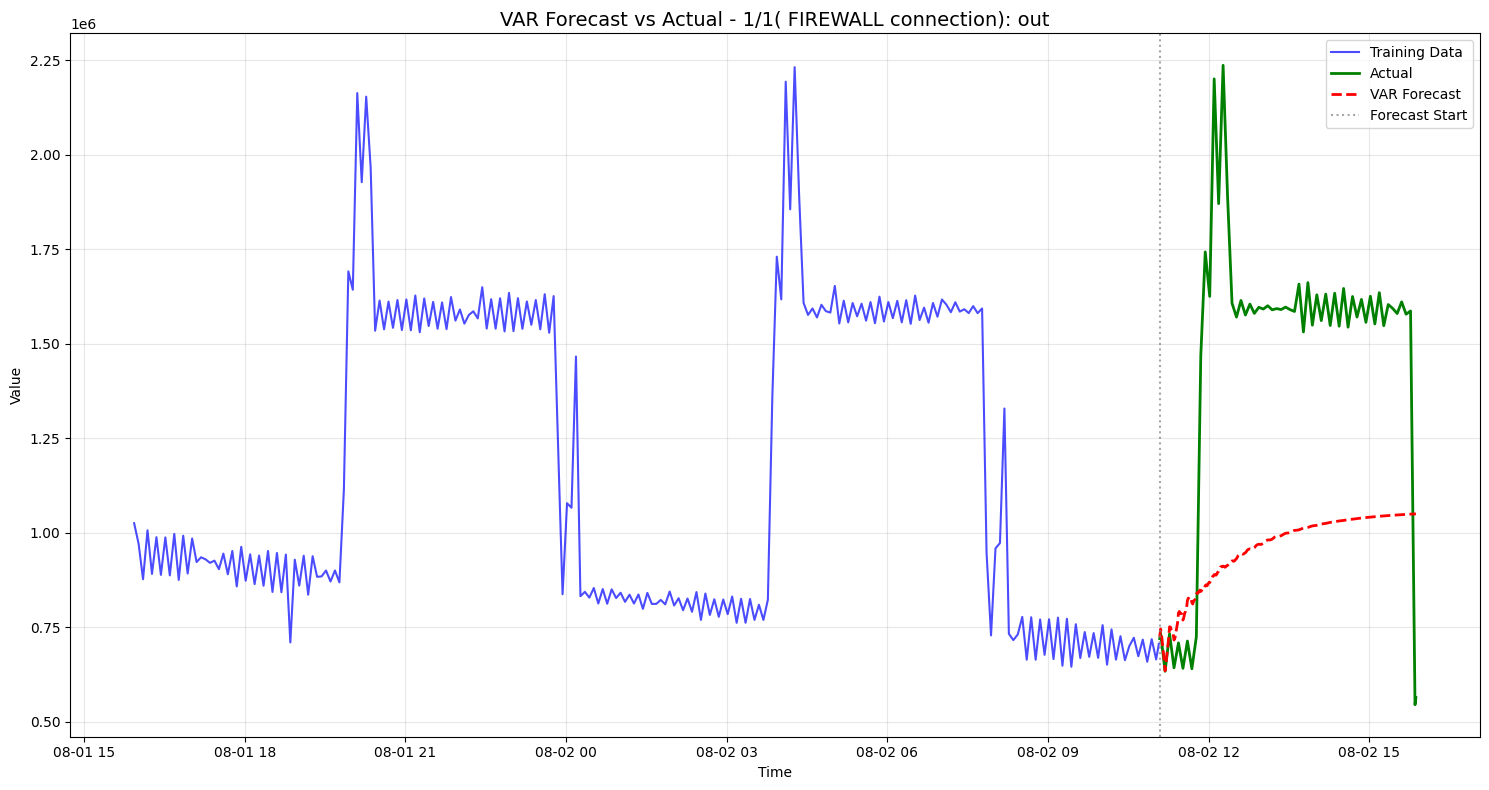

Metrics for 1/1( FIREWALL connection): out:
MAE: 546397.7857, RMSE: 603203.4731


In [99]:
plot_single_variable_forecast(
    variable_idx=1,
    train_data_normalized=train_data_normalized,
    test_data_denormalized=test_data_denormalized,
    VAR_forecast_denormalized=VAR_forecast_denormalized,
    scaler=scaler,
    results_df=VAR_results_df
)

Merged approach, forecasting the residuals using TimesFM.

In [106]:
# add column names to VAR_forecast
VAR_forecast = pd.DataFrame(VAR_forecast, columns=test_data_denormalized.columns)
VAR_forecast.columns = [f"{col}" for col in VAR_forecast.columns]

residuals = {}

# calculate residuals for each variable
for col in VAR_forecast.columns:
    residuals[col] = test_data_denormalized[col].values - VAR_forecast[col].values

In [107]:
# Calculate residuals for each variable in the test set
residuals = test_data_denormalized - VAR_forecast_denormalized
df_residuals = pd.DataFrame(residuals, columns=test_data_denormalized.columns)

In [102]:
# TimesFM model for forecasting values of residuals

